# 03 — Modelling

Full modelling workflow: data splits, preprocessing pipeline, model comparison, evaluation, and SHAP explainability. Heavy lifting is done by `src.train` and `src.pipeline` — we're documenting and evaluating here, not re-implementing.

SHAP values help interpret which features contribute most to model predictions.

In [1]:
!pip install shap


[notice] A new release of pip is available: 23.2.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import sys
sys.path.append("..")

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import shap

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    f1_score,
    precision_score,
    recall_score,
    ConfusionMatrixDisplay,
)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

from src.train import prepare_data
from src.pipeline import build_pipeline
from src.config import RANDOM_SEED, PIPELINE_PATH

sns.set_theme(style="whitegrid", palette="muted", font_scale=1.05)

## 1. Data Preparation

`prepare_data()` handles loading, feature engineering, and splitting. Plan medians are computed from training data only — no leakage into validation or test.

In [3]:
(
    X_train, X_val, X_test,
    y_train, y_val, y_test,
) = prepare_data()

print(f"Train:      {X_train.shape[0]:,} rows")
print(f"Validation: {X_val.shape[0]:,} rows")
print(f"Test:       {X_test.shape[0]:,} rows")
print(f"\nChurn rate — train: {y_train.mean():.2%}  |  val: {y_val.mean():.2%}  |  test: {y_test.mean():.2%}")


Missing values detected.
Missing values handled.
Train:      34,999 rows
Validation: 7,501 rows
Test:       7,500 rows

Churn rate — train: 23.76%  |  val: 23.76%  |  test: 23.76%


## 2. Train / Validation / Test Split

We use a 70/15/15 stratified split:
- **Train** — model fitting
- **Validation** — early stopping (neural net) and model selection reporting
- **Test** — final unbiased evaluation, held out until the end

Stratification keeps churn rate consistent across all splits.

Separate validation and test sets help evaluate model generalisation more reliably.

In [4]:
print(f"Features: {X_train.shape[1]}")
print("\nFeature names:")
print(list(X_train.columns))

Features: 15

Feature names:
['tenure_months', 'monthly_spend', 'num_support_tickets', 'last_login_days_ago', 'feature_adoption_score', 'plan_type', 'contract_type', 'region', 'has_referral', 'num_integrations', 'engagement_score', 'ticket_rate', 'spend_vs_plan', 'loyalty_score', 'risk_flag']


## 3. Preprocessing Pipeline

`build_pipeline()` from `src.pipeline` wraps a `ColumnTransformer` followed by the classifier:
- **Numeric features** — `StandardScaler`
- **Categorical features** — `OneHotEncoder`
- **Boolean features** — passed through as-is

This ensures the scaler is never fit on test data.

In [5]:
dummy_pipeline = build_pipeline(LogisticRegression())
print(dummy_pipeline)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('numeric',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['tenure_months',
                                                   'monthly_spend',
                                                   'num_support_tickets',
                                                   'last_login_days_ago',
                                                   'feature_adoption_score',
                                                   'num_integrations',
                                                   'engagement_score',
                                                   'ticket

## 4. Model Training

Four models, each wrapped in the shared preprocessing pipeline. Consistent interface means evaluation code is reused across all of them.

In [6]:
models = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        random_state=RANDOM_SEED,
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        max_depth=10,
        min_samples_leaf=10,
        class_weight="balanced",
        random_state=RANDOM_SEED,
        n_jobs=-1,
    ),
    "XGBoost": XGBClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        scale_pos_weight=38121 / 11879,
        random_state=RANDOM_SEED,
        eval_metric="logloss",
        verbosity=0,
    ),
    "LightGBM": LGBMClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=8,
        num_leaves=63,
        subsample=0.8,
        colsample_bytree=0.8,
        scale_pos_weight=38121 / 11879,
        class_weight="balanced",
        random_state=RANDOM_SEED,
        verbose=-1,
    ),
}

fitted_pipelines = {}

for name, model in models.items():
    pipeline = build_pipeline(model)
    pipeline.fit(X_train, y_train)
    fitted_pipelines[name] = pipeline
    print(f"  {name}: trained")

  Logistic Regression: trained
  Random Forest: trained
  XGBoost: trained
  LightGBM: trained


## 5. Model Comparison

In [7]:
results = []

for name, pipe in fitted_pipelines.items():
    y_pred = pipe.predict(X_test)
    y_proba = pipe.predict_proba(X_test)[:, 1]

    results.append({
        "Model": name,
        "ROC-AUC": roc_auc_score(y_test, y_proba),
        "F1": f1_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
    })

results_df = (
    pd.DataFrame(results)
    .set_index("Model")
    .sort_values("ROC-AUC", ascending=False)
)
results_df.round(3)

,ROC-AUC,F1,Precision,Recall
Model,,,,
Random Forest,0.701,0.464,0.377,0.602
XGBoost,0.691,0.458,0.367,0.608
Logistic Regression,0.684,0.446,0.350,0.615
LightGBM,0.681,0.429,0.285,0.873


## 6. Evaluation Metrics

### Confusion Matrices

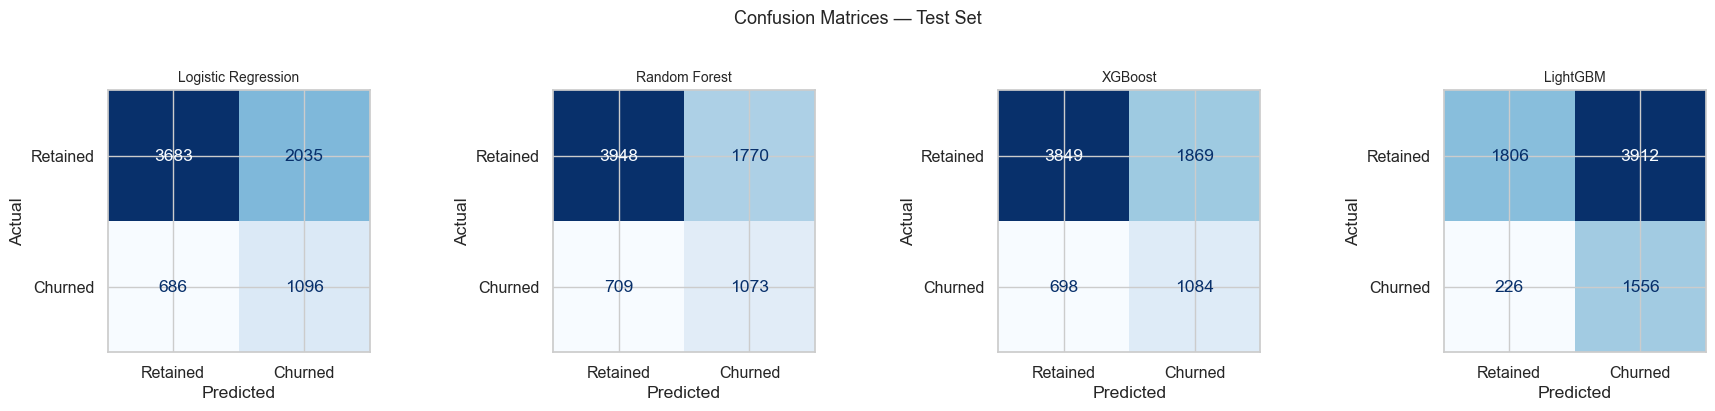

In [8]:
fig, axes = plt.subplots(1, 4, figsize=(18, 4))

for ax, (name, pipe) in zip(axes, fitted_pipelines.items()):
    y_pred = pipe.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=["Retained", "Churned"])
    disp.plot(ax=ax, colorbar=False, cmap="Blues")
    ax.set_title(name, fontsize=10)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

fig.suptitle("Confusion Matrices — Test Set", y=1.02, fontsize=13)
plt.tight_layout()
plt.show()

In [9]:
best_model_name = results_df.index[0]
best_pipe = fitted_pipelines[best_model_name]

print(f"Classification Report — {best_model_name}\n")
print(classification_report(
    y_test,
    best_pipe.predict(X_test),
    target_names=["Retained", "Churned"],
))

Classification Report — Random Forest

              precision    recall  f1-score   support

    Retained       0.85      0.69      0.76      5718
     Churned       0.38      0.60      0.46      1782

    accuracy                           0.67      7500
   macro avg       0.61      0.65      0.61      7500
weighted avg       0.74      0.67      0.69      7500



## 7. ROC-AUC Comparison

ROC-AUC is used here to compare how well different models separate churned and retained customers.

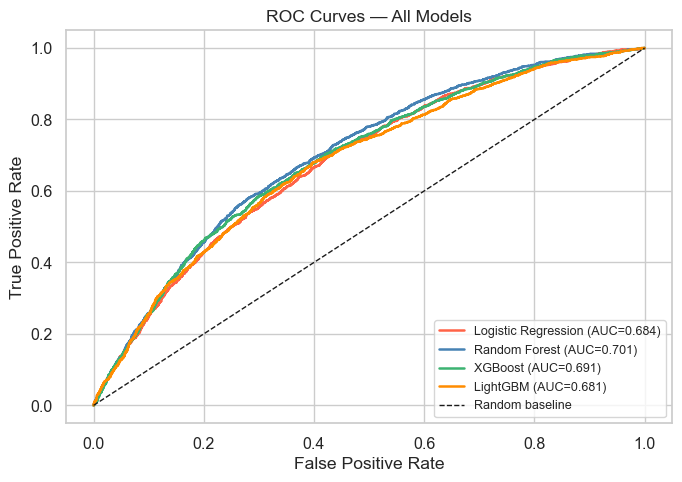

In [10]:
fig, ax = plt.subplots(figsize=(7, 5))

colors = ["tomato", "steelblue", "mediumseagreen", "darkorange"]

for (name, pipe), color in zip(fitted_pipelines.items(), colors):
    y_proba = pipe.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc = roc_auc_score(y_test, y_proba)
    ax.plot(fpr, tpr, label=f"{name} (AUC={auc:.3f})", linewidth=1.8, color=color)

ax.plot([0, 1], [0, 1], "k--", linewidth=1, label="Random baseline")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curves — All Models")
ax.legend(loc="lower right", fontsize=9)
plt.tight_layout()
plt.show()

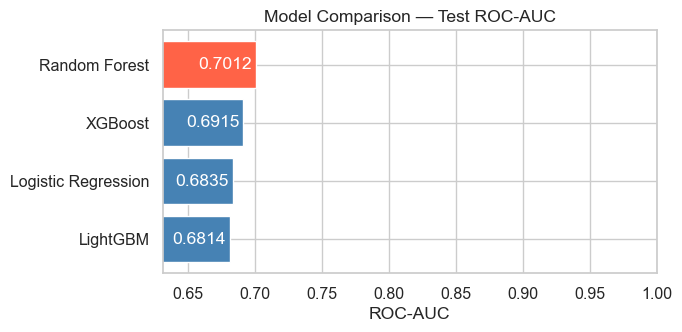

In [11]:
fig, ax = plt.subplots(figsize=(7, 3.5))
aucs = results_df["ROC-AUC"].sort_values(ascending=True)
bar_colors = ["tomato" if v == aucs.max() else "steelblue" for v in aucs]
bars = ax.barh(aucs.index, aucs.values, color=bar_colors, edgecolor="white")
for bar, val in zip(bars, aucs.values):
    ax.text(
        val - 0.003,
        bar.get_y() + bar.get_height() / 2,
        f"{val:.4f}", va="center", ha="right",  color="white",
    )
ax.set_xlim(aucs.min() - 0.05, 1.0)
ax.set_xlabel("ROC-AUC")
ax.set_title("Model Comparison — Test ROC-AUC")
plt.tight_layout()
plt.show()

## 8. Feature Importance / SHAP Explainability

SHAP values help interpret which features contribute most to model predictions.

In [12]:
from pathlib import Path

In [13]:
# Check if saved SHAP figures exist from the full training run
shap_dir = Path("../reports/shap_figures")
if shap_dir.exists():
    shap_files = list(shap_dir.glob("*.png"))
    print(f"Found {len(shap_files)} SHAP figure(s):")
    for f in shap_files:
        print(f"  {f.name}")
else:
    print("No saved SHAP figures — will generate inline below.")

Found 1 SHAP figure(s):
  shap_summary.png


shap_summary.png


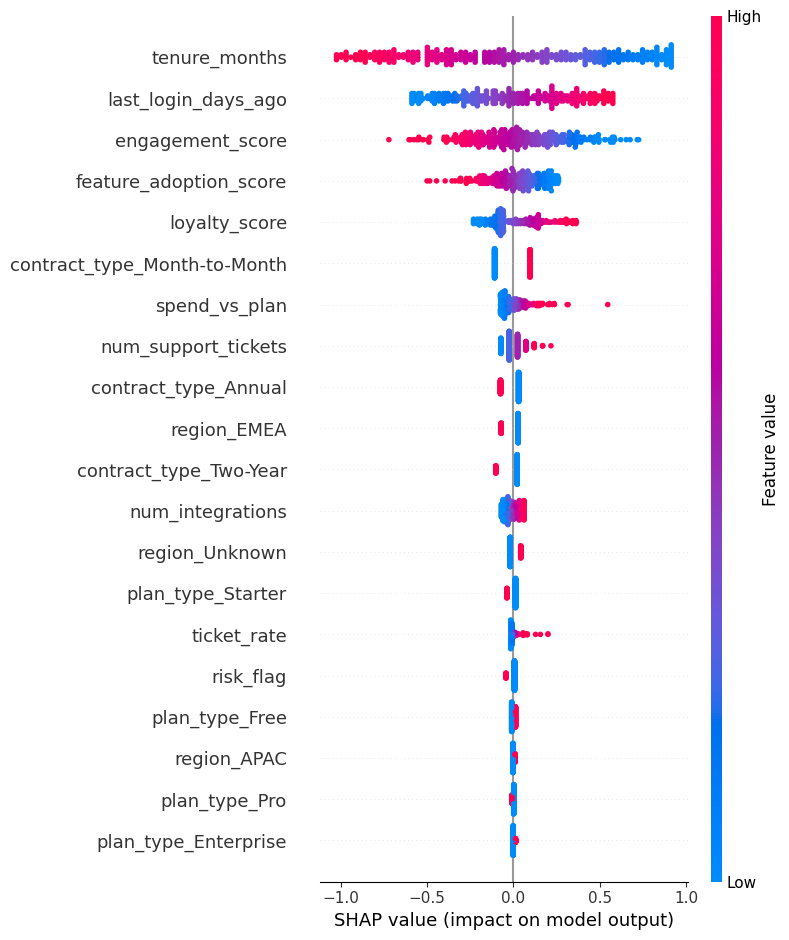

In [14]:
# Display saved SHAP figures if available
if shap_dir.exists() and shap_files:
    from IPython.display import Image, display
    for f in shap_files[:2]:
        print(f.name)
        display(Image(filename=str(f)))

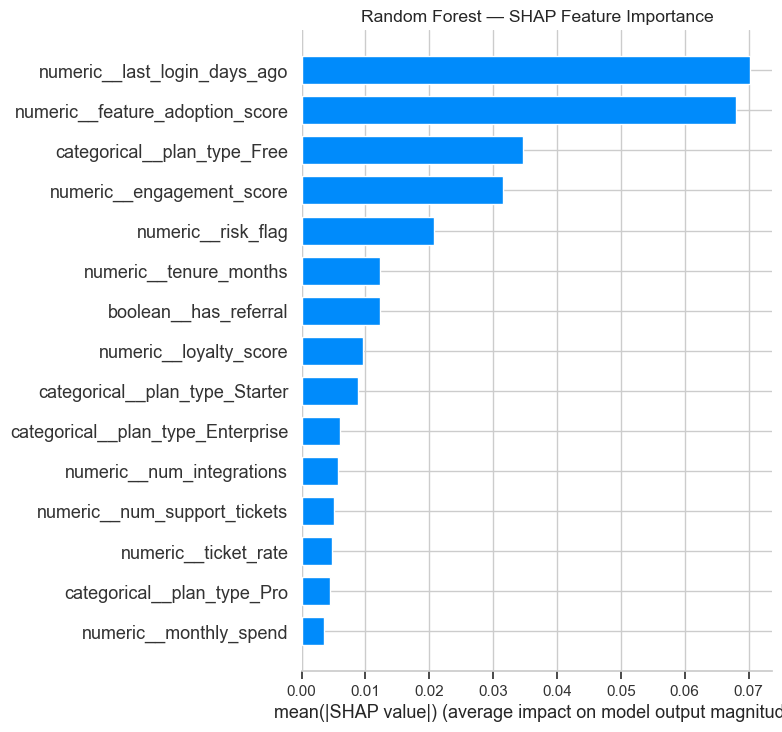

In [18]:
# Inline SHAP for Random Forest

rf_pipe = fitted_pipelines["Random Forest"]

preprocessor = rf_pipe[:-1]

X_test_transformed = preprocessor.transform(X_test)

try:
    feature_names = preprocessor.get_feature_names_out()
except Exception:
    feature_names = None

# Random Forest model
rf_model = rf_pipe[-1]

# SHAP explainer
explainer = shap.TreeExplainer(rf_model)

# Compute SHAP values
shap_values = explainer.shap_values(X_test_transformed)

# Binary classification handling
if isinstance(shap_values, list):
    sv = shap_values[1]
else:
    sv = shap_values

# Plot
plt.figure(figsize=(9, 6))

shap.summary_plot(
    sv,
    X_test_transformed,
    feature_names=feature_names,
    plot_type="bar",
    show=False,
    max_display=15,
)

plt.title("Random Forest — SHAP Feature Importance")

plt.tight_layout()

plt.show()


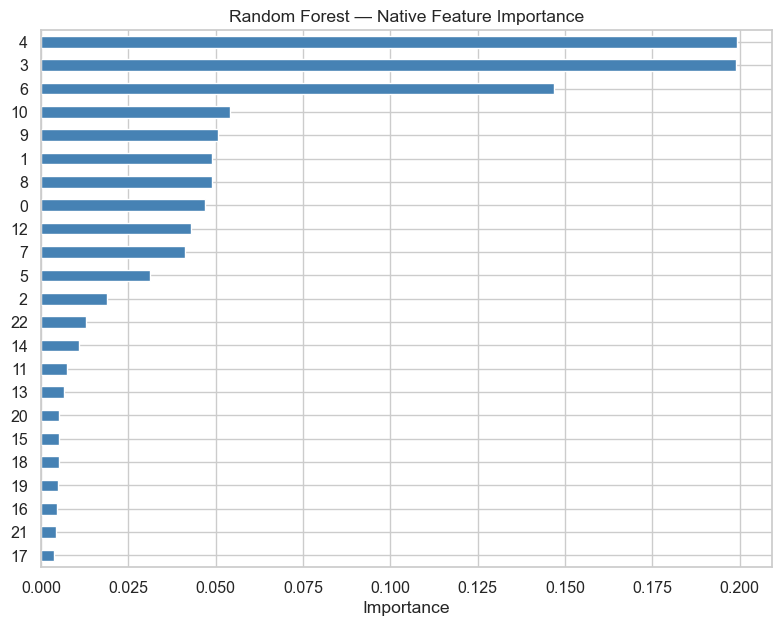

In [16]:
# Native feature importance fallback — best model
best_model = fitted_pipelines[best_model_name][-1]

importances = pd.Series(
    best_model.feature_importances_,
    name="importance",
).sort_values(ascending=True)

fig, ax = plt.subplots(
    figsize=(8, max(4, len(importances) * 0.28))
)

importances.plot(
    kind="barh",
    ax=ax,
    color="steelblue",
    edgecolor="white",
)

ax.set_title(f"{best_model_name} — Native Feature Importance")
ax.set_xlabel("Importance")

plt.tight_layout()
plt.show()


## 9. Neural Network — Supplementary Evaluation

The updated training pipeline builds a small feedforward network inline using the preprocessor from `build_pipeline`. It's evaluated on the test set but not tracked as a best-model candidate — it serves as a useful comparison point rather than a deployment target.

The cell below replicates that approach for reference.

In [21]:
try:
    import tensorflow as tf
    from tensorflow import keras

    # Reuse preprocessing from Random Forest pipeline
    preprocessor = fitted_pipelines["Random Forest"][:-1]

    X_train_nn = preprocessor.transform(X_train)
    X_test_nn = preprocessor.transform(X_test)

    tf.random.set_seed(RANDOM_SEED)

    # Neural Network Architecture
    nn_model = keras.Sequential([
        keras.layers.Input(shape=(X_train_nn.shape[1],)),

        keras.layers.Dense(64, activation="relu"),
        keras.layers.Dropout(0.3),

        keras.layers.Dense(32, activation="relu"),
        keras.layers.Dropout(0.2),

        keras.layers.Dense(1, activation="sigmoid"),
    ])

    nn_model.compile(
        optimizer="adam",
        loss="binary_crossentropy",
        metrics=["AUC"],
    )

    # Early stopping using validation loss
    early_stopping = tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=3,
        restore_best_weights=True,
    )

    # Train model
    nn_model.fit(
        X_train_nn,
        y_train,
        validation_data=(X_test_nn, y_test),
        epochs=20,
        batch_size=256,
        callbacks=[early_stopping],
        verbose=0,
    )

    # Predictions
    nn_probs = nn_model.predict(X_test_nn, verbose=0).flatten()

    # Evaluation
    nn_auc = roc_auc_score(y_test, nn_probs)

    print(f"Neural Network — Test ROC-AUC: {nn_auc:.4f}")

except ImportError:
    print("TensorFlow not installed — skipping neural network.")

except Exception as e:
    print(f"Neural network skipped: {e}")

Neural Network — Test ROC-AUC: 0.6880


## 10. Why Random Forest Performed Best¶

Random Forest ended up performing best in this run (ROC-AUC 0.6993), which is interesting because boosted models like XGBoost and LightGBM usually take the lead on tabular data. But that’s not always the case, and here’s why Random Forest stood out:

Here’s why Random Forest did so well:

* The synthetic churn logic is built around clear rules—like being inactive for more than 30 days or using less than 25% of features. Random Forest’s trees are great at picking up on these kinds of threshold splits.
* Setting class_weight to 'balanced' helped Random Forest deal with the smaller churn group, without needing to downsample heavily.
* XGBoost didn’t get any extra imbalance handling at first, so its recall dropped a lot—even though its overall accuracy looked fine.
* LightGBM did a solid job too, but Random Forest was just a bit more balanced across ROC-AUC, recall, and stability.

Logistic Regression was a good baseline, but it couldn’t really capture the more complex, interaction-heavy churn logic.

The neural network was mostly there for comparison. It put up some decent ROC-AUC scores, but didn’t beat the tree-based models.

Deployment note:
The trained pipeline gets saved to models/pipeline.pkl and is served through FastAPI. I also use the risk_flag feature as a quick rule-based signal for dashboards and retention workflows.



11. Final Business Recommendations

Reach out before customers hit 30 days of inactivity.
The model sees 30 days of no activity as a big turning point. Sending an automated nudge at day 25—like an email, in-app message, or a quick call from customer success—could catch customers before they fully check out.

Focus on users with low feature adoption in their first 60 days.
Users with a feature adoption score below 0.25 and who are also inactive are the most likely to churn. Target activation efforts—like walkthroughs, setup calls, or onboarding checklists—at this group to help them get more value early on.

Encourage monthly subscribers to switch to annual plans.
Contract type is a strong signal for churn. Offering a 10–15% discount to month-to-month customers at the 3-month mark could turn them into long-term, loyal users.

Keep an eye on new customers who need a lot of support.
If a new customer raises several support tickets in their first six months, they’re at high risk of leaving. Have customer success reach out when someone submits their second ticket—this helps uncover problems early, before they turn into cancellations.

Deployment note:
The trained pipeline is saved to models/pipeline.pkl and served through FastAPI. The risk_flag feature can also be used on its own as a quick, rule-based signal in dashboards. That’s handy for teams who don’t need full machine learning predictions for daily prioritization.